<a href="https://www.kaggle.com/code/klimyuriy/titanic-survival-predict?scriptVersionId=233689293" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
training_df = pd.read_csv("/kaggle/input/titanic/train.csv")
testing_df = pd.read_csv("/kaggle/input/titanic/test.csv")

In [3]:
print(training_df.shape)
training_df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print(testing_df.shape)
testing_df.head()

(418, 11)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
training_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
testing_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [7]:
training_df['Age'] = training_df.groupby(['Pclass', 'Sex', 'Parch'])['Age'].transform(lambda x: x.fillna(x.median()))
testing_df['Age'] = testing_df.groupby(['Pclass', 'Sex', 'Parch'])['Age'].transform(lambda x: x.fillna(x.median()))

In [8]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
testing_df['Age'] = testing_df.groupby(['Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
testing_df['Fare'] = testing_df.groupby(['Pclass', 'Sex', 'Parch'])['Fare'].transform(lambda x: x.fillna(x.median()))
testing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [10]:
training_df['Deck'] = training_df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else np.nan)

In [11]:
testing_df['Deck'] = testing_df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else np.nan)

In [12]:
training_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,NaN
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,B
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,9.5,1,2,W./C. 6607,23.4500,NaN,S,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,C


In [13]:
set(training_df['Deck'])

{'A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', nan}

In [14]:
deck_survival = training_df.groupby('Deck')['Survived'].mean().sort_values(ascending=False)
print(deck_survival)

Deck
D    0.757576
E    0.750000
B    0.744681
F    0.615385
C    0.593220
G    0.500000
A    0.466667
T    0.000000
Name: Survived, dtype: float64


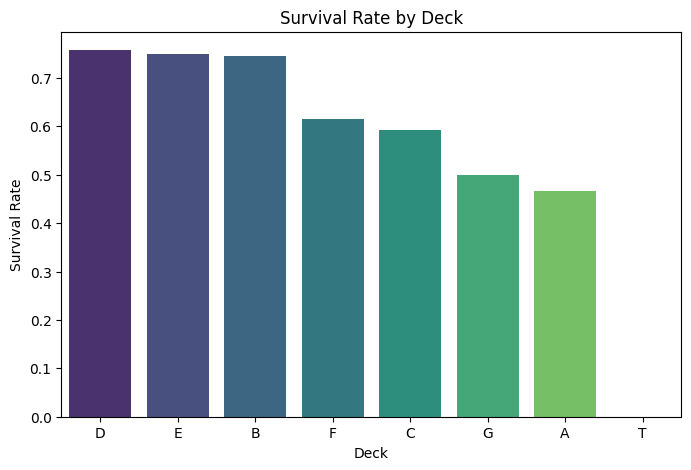

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x=deck_survival.index, y=deck_survival.values, palette='viridis')
plt.xlabel('Deck')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Deck')
plt.show()

In [16]:
most_common_deck = training_df.groupby('Pclass')['Deck'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'U')
training_df['Deck'] = training_df.apply(lambda row: most_common_deck[row['Pclass']] if pd.isnull(row['Deck']) else row['Deck'], axis=1)

In [17]:
training_df.drop(columns=['Cabin'], inplace=True)

In [18]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
 11  Deck         891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
most_common_deck = testing_df.groupby('Pclass')['Deck'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'U')
testing_df['Deck'] = testing_df.apply(lambda row: most_common_deck[row['Pclass']] if pd.isnull(row['Deck']) else row['Deck'], axis=1)

In [20]:
testing_df.drop(columns=['Cabin'], inplace=True)

In [21]:
testing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Embarked     418 non-null    object 
 10  Deck         418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [22]:
training_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [23]:
training_df['Embarked'].fillna('S', inplace=True)
print(training_df.isnull().sum())
print(testing_df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Deck           0
dtype: int64
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Deck           0
dtype: int64


/tmp/ipykernel_97/3706262653.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  training_df['Embarked'].fillna('S', inplace=True)


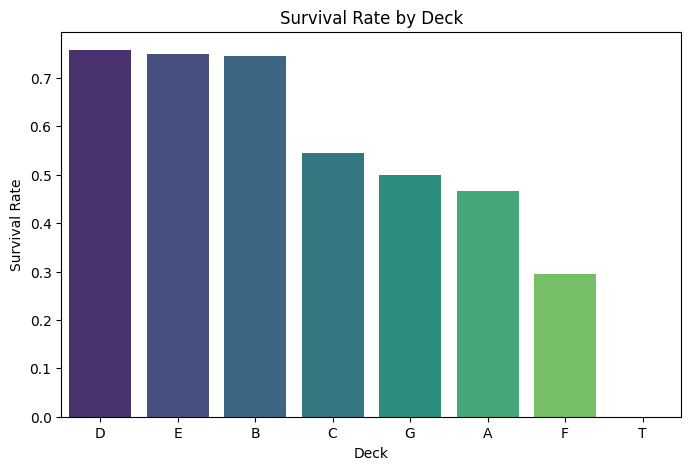

In [24]:
deck_survival = training_df.groupby('Deck')['Survived'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=deck_survival.index, y=deck_survival.values, palette='viridis')
plt.xlabel('Deck')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Deck')
plt.show()

In [25]:
X = training_df.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'])
y = training_df['Survived']

In [26]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
0,3,male,22.0,1,0,7.2500,S,F
1,1,female,38.0,1,0,71.2833,C,C
2,3,female,26.0,0,0,7.9250,S,F
3,1,female,35.0,1,0,53.1000,S,C
4,3,male,35.0,0,0,8.0500,S,F
...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,F
887,1,female,19.0,0,0,30.0000,S,B
888,3,female,9.5,1,2,23.4500,S,F
889,1,male,26.0,0,0,30.0000,C,C


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                    train_size=0.8,
                                                    random_state=42)

In [28]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_columns = X.select_dtypes(include="number").columns
cat_columns = X.select_dtypes(include="object").columns

num_transformer = Pipeline(
    steps=[("scaler", StandardScaler())]
    )

cat_transformer = Pipeline(
    steps=[("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value =-1))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_columns),
        ("cat", cat_transformer, cat_columns)
    ]
)

preprocessor.set_output(transform='pandas')
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 Index(['Sex', 'Embarked', 'Deck'], dtype='object'))])

In [29]:
X_train = preprocessor.fit_transform(X_train)

X_val = preprocessor.transform(X_val)

In [30]:
!pip install optuna

In [31]:
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# def tune_hyperparameters(X_train, X_val, y_train, y_val, algorithm, n_trials):
#     """
#     A function for optimizing hyperparameters with Optuna for a given algorithm.

#     Params:
#         X_train, X_test, y_train, y_test - training and test data.
#         algorithm - name of the algorithm (one of them: "DT" - DecisionTree, "RF" - RandomForest,
#                                           "GBDT" - Gradient Boosting Decision Trees, "XGB" - XGBoost).
#         n_trials - the number of optimization iterations.

#     Return:
#         Dictionary with optimal hyperparameters.
#     """

#     def objective(trial):
#         if algorithm == "DT":
#             max_depth = trial.suggest_int("max_depth", 1, 64)
#             min_samples_split = trial.suggest_int("min_samples_split", 2, 50)
#             min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 50)
#             model = DecisionTreeClassifier(max_depth=max_depth,
#                                            min_samples_split=min_samples_split,
#                                            min_samples_leaf=min_samples_leaf,
#                                            random_state=42)

#         elif algorithm == "RF":
#             n_estimators = trial.suggest_int("n_estimators", 50, 300)
#             max_depth = trial.suggest_int("max_depth", 1, 64)
#             min_samples_split = trial.suggest_int("min_samples_split", 2, 50)
#             min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 50)
#             model = RandomForestClassifier(n_estimators=n_estimators,
#                                            max_depth=max_depth,
#                                            min_samples_split=min_samples_split,
#                                            min_samples_leaf=min_samples_leaf,
#                                            random_state=42)

#         elif algorithm == "GBDT":
#             n_estimators = trial.suggest_int("n_estimators", 50, 300)
#             learning_rate = trial.suggest_float("learning_rate", 0.001, 0.3)
#             max_depth = trial.suggest_int("max_depth", 1, 50)
#             subsample = trial.suggest_float("subsample", 0.5, 1.0)
#             model = GradientBoostingClassifier(n_estimators=n_estimators,
#                                                learning_rate=learning_rate,
#                                                max_depth=max_depth,
#                                                subsample=subsample,
#                                                random_state=42)

#         elif algorithm == "XGB":
#             n_estimators = trial.suggest_int("n_estimators", 50, 500)
#             learning_rate = trial.suggest_float("learning_rate", 0.001, 0.3)
#             max_depth = trial.suggest_int("max_depth", 1, 100)
#             gamma = trial.suggest_float("gamma", 0, 1.0)
#             subsample = trial.suggest_float("subsample", 0.5, 1.0)
#             reg_alpha = trial.suggest_float("reg_alpha", 0, 20.0)
#             reg_lambda = trial.suggest_float("reg_lambda", 0, 20.0)
#             max_leaves = trial.suggest_int("max_leaves", 0, 1000)
#             colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
#             num_parallel_tree = trial.suggest_int("num_parallel_tree", 1, 100)
#             model = XGBClassifier(n_estimators=n_estimators,
#                                   learning_rate=learning_rate,
#                                   max_depth=max_depth,
#                                   gamma=gamma,
#                                   subsample=subsample,
#                                   reg_alpha=reg_alpha,
#                                   reg_lambda=reg_lambda,
#                                   max_leaves=max_leaves,
#                                   colsample_bytree=colsample_bytree,
#                                   num_parallel_tree=num_parallel_tree,
#                                   eval_metric='logloss',
#                                   random_state=42)

#         else:
#             raise ValueError(f"Unsupported algorithm: {algorithm}")

#         # Model training
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_val)
#         score = accuracy_score(y_val, y_pred)

#         # Since Optuna minimizes the objective function, we return (1 - accuracy)
#         return 1 - score

#     # Creating and optimizing research
#     study = optuna.create_study()
#     study.optimize(objective, n_trials=n_trials)

#     return study.best_params

In [32]:
# best_params = tune_hyperparameters(X_train, X_val, y_train, y_val, "XGB", 1000)

# best_params

In [33]:
best_params = {'n_estimators': 2000,
            'learning_rate': 0.02,
            'max_depth': 30,
            'gamma': 0.12125126317286972,
            'subsample': 0.8732306883363055,
            'reg_alpha': 0.9590660764279347,
            'reg_lambda': 16.619807006308523,
            'max_leaves': 410,
            'colsample_bytree': 0.5210397154615065,
            'num_parallel_tree': 83}

In [34]:
X = preprocessor.fit_transform(X)

In [35]:
clf = XGBClassifier(**best_params, eval_metric='logloss', random_state=42)
clf.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5210397154615065, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=0.12125126317286972, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=30, max_leaves=410,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2000, n_jobs=None,
              num_parallel_tree=83, random_state=42, ...)

In [36]:
X_test = testing_df.drop(columns=['Name', 'Ticket', 'PassengerId'])

In [37]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
0,3,male,34.5,0,0,7.8292,Q,F
1,3,female,47.0,1,0,7.0000,S,F
2,2,male,62.0,0,0,9.6875,Q,F
3,3,male,27.0,0,0,8.6625,S,F
4,3,female,22.0,1,1,12.2875,S,F
...,...,...,...,...,...,...,...,...
413,3,male,25.0,0,0,8.0500,S,F
414,1,female,39.0,0,0,108.9000,C,C
415,3,male,38.5,0,0,7.2500,S,F
416,3,male,25.0,0,0,8.0500,S,F


In [38]:
test_df = preprocessor.fit_transform(X_test)

In [39]:
test_df['Survived'] = clf.predict(test_df)

test_df

,num__Pclass,num__Age,num__SibSp,num__Parch,num__Fare,cat__Sex,cat__Embarked,cat__Deck,Survived
0,0.873482,0.389425,-0.499470,-0.400248,-0.497069,1.0,1.0,5.0,0
1,0.873482,1.348984,0.616992,-0.400248,-0.511932,0.0,2.0,5.0,0
2,-0.315819,2.500455,-0.499470,-0.400248,-0.463760,1.0,1.0,5.0,0
3,0.873482,-0.186311,-0.499470,-0.400248,-0.482132,1.0,2.0,5.0,0
4,0.873482,-0.570134,0.616992,0.619896,-0.417157,0.0,2.0,5.0,0
...,...,...,...,...,...,...,...,...,...
413,0.873482,-0.339840,-0.499470,-0.400248,-0.493111,1.0,2.0,5.0,0
414,-1.505120,0.734866,-0.499470,-0.400248,1.314555,0.0,0.0,2.0,1
415,0.873482,0.696484,-0.499470,-0.400248,-0.507450,1.0,2.0,5.0,0
416,0.873482,-0.339840,-0.499470,-0.400248,-0.493111,1.0,2.0,5.0,0


In [40]:
output = pd.DataFrame({'PassengerId': testing_df.PassengerId, 'Survived': test_df.Survived})
output.to_csv('submission1.csv', index=False)